# ECG Signal Classification using Machine Learning
## Heartbeat Normal vs Abnormal Detection

**Dataset:** MIT-BIH Arrhythmia Database (mitbih_train.csv / mitbih_test.csv)




## Library Import 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Signal processing
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, roc_curve, auc
)

from sklearn.preprocessing import label_binarize
np.random.seed(42)



## Data Loading

In [2]:
train_df = pd.read_csv('dataset/mitbih_train.csv', header=None)
test_df  = pd.read_csv('dataset/mitbih_test.csv',  header=None)

print("Training set shape :", train_df.shape)
print("Test set shape     :", test_df.shape)
print("\nFirst 3 rows of training data:")
train_df.head(3)

Training set shape : (87554, 188)
Test set shape     : (21892, 188)

First 3 rows of training data:


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train_raw = train_df.iloc[:, :-1].values
y_train     = train_df.iloc[:, -1].values.astype(int)

X_test_raw  = test_df.iloc[:, :-1].values
y_test      = test_df.iloc[:, -1].values.astype(int)

class_names = [
    'Normal (0)',
    'Supraventricular (1)',
    'Ventricular (2)',
    'Fusion (3)',
    'Unknown (4)'
]

print("X_train shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)
print("Unique classes:", np.unique(y_train))

X_train shape: (87554, 187)
y_train shape: (87554,)
Unique classes: [0 1 2 3 4]


## Exploratory Data Analysis (EDA)


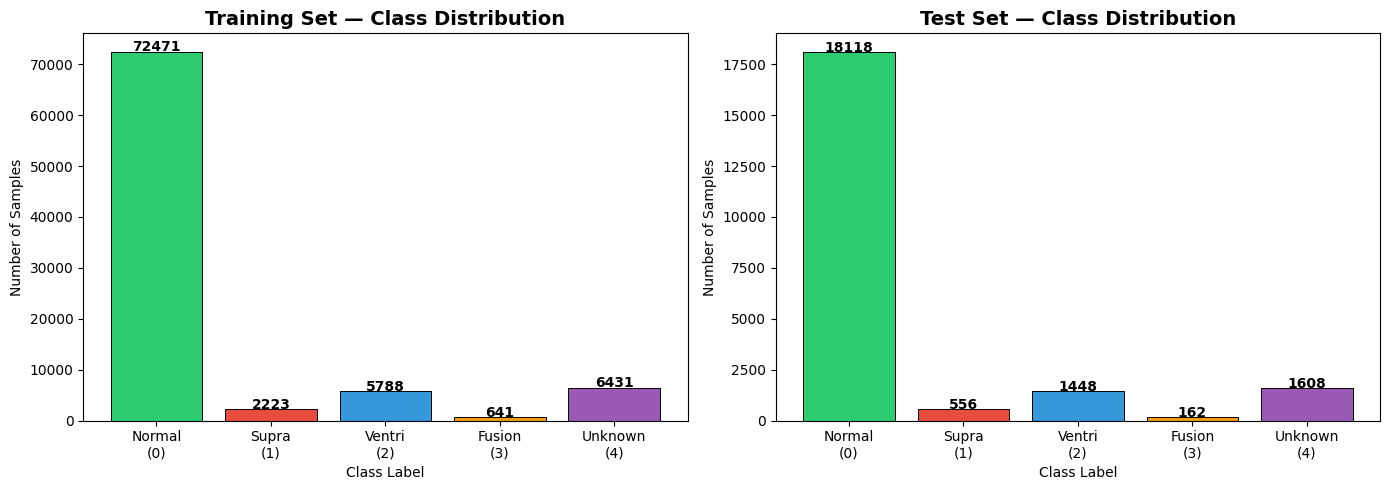


 Class distribution (Training):
  Class 0 (Normal (0)): 72,471 samples (82.8%)
  Class 1 (Supraventricular (1)): 2,223 samples (2.5%)
  Class 2 (Ventricular (2)): 5,788 samples (6.6%)
  Class 3 (Fusion (3)): 641 samples (0.7%)
  Class 4 (Unknown (4)): 6,431 samples (7.3%)


In [4]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

# Training set
axes[0].bar(range(5), train_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Training Set — Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['Normal\n(0)', 'Supra\n(1)', 'Ventri\n(2)', 'Fusion\n(3)', 'Unknown\n(4)'])
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=10)

# Test set
axes[1].bar(range(5), test_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[1].set_title('Test Set — Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class Label')
axes[1].set_ylabel('Number of Samples')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(['Normal\n(0)', 'Supra\n(1)', 'Ventri\n(2)', 'Fusion\n(3)', 'Unknown\n(4)'])
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Class distribution (Training):")
for i, (count) in enumerate(train_counts.values):
    pct = count / len(y_train) * 100
    print(f"  Class {i} ({class_names[i]}): {count:,} samples ({pct:.1f}%)")

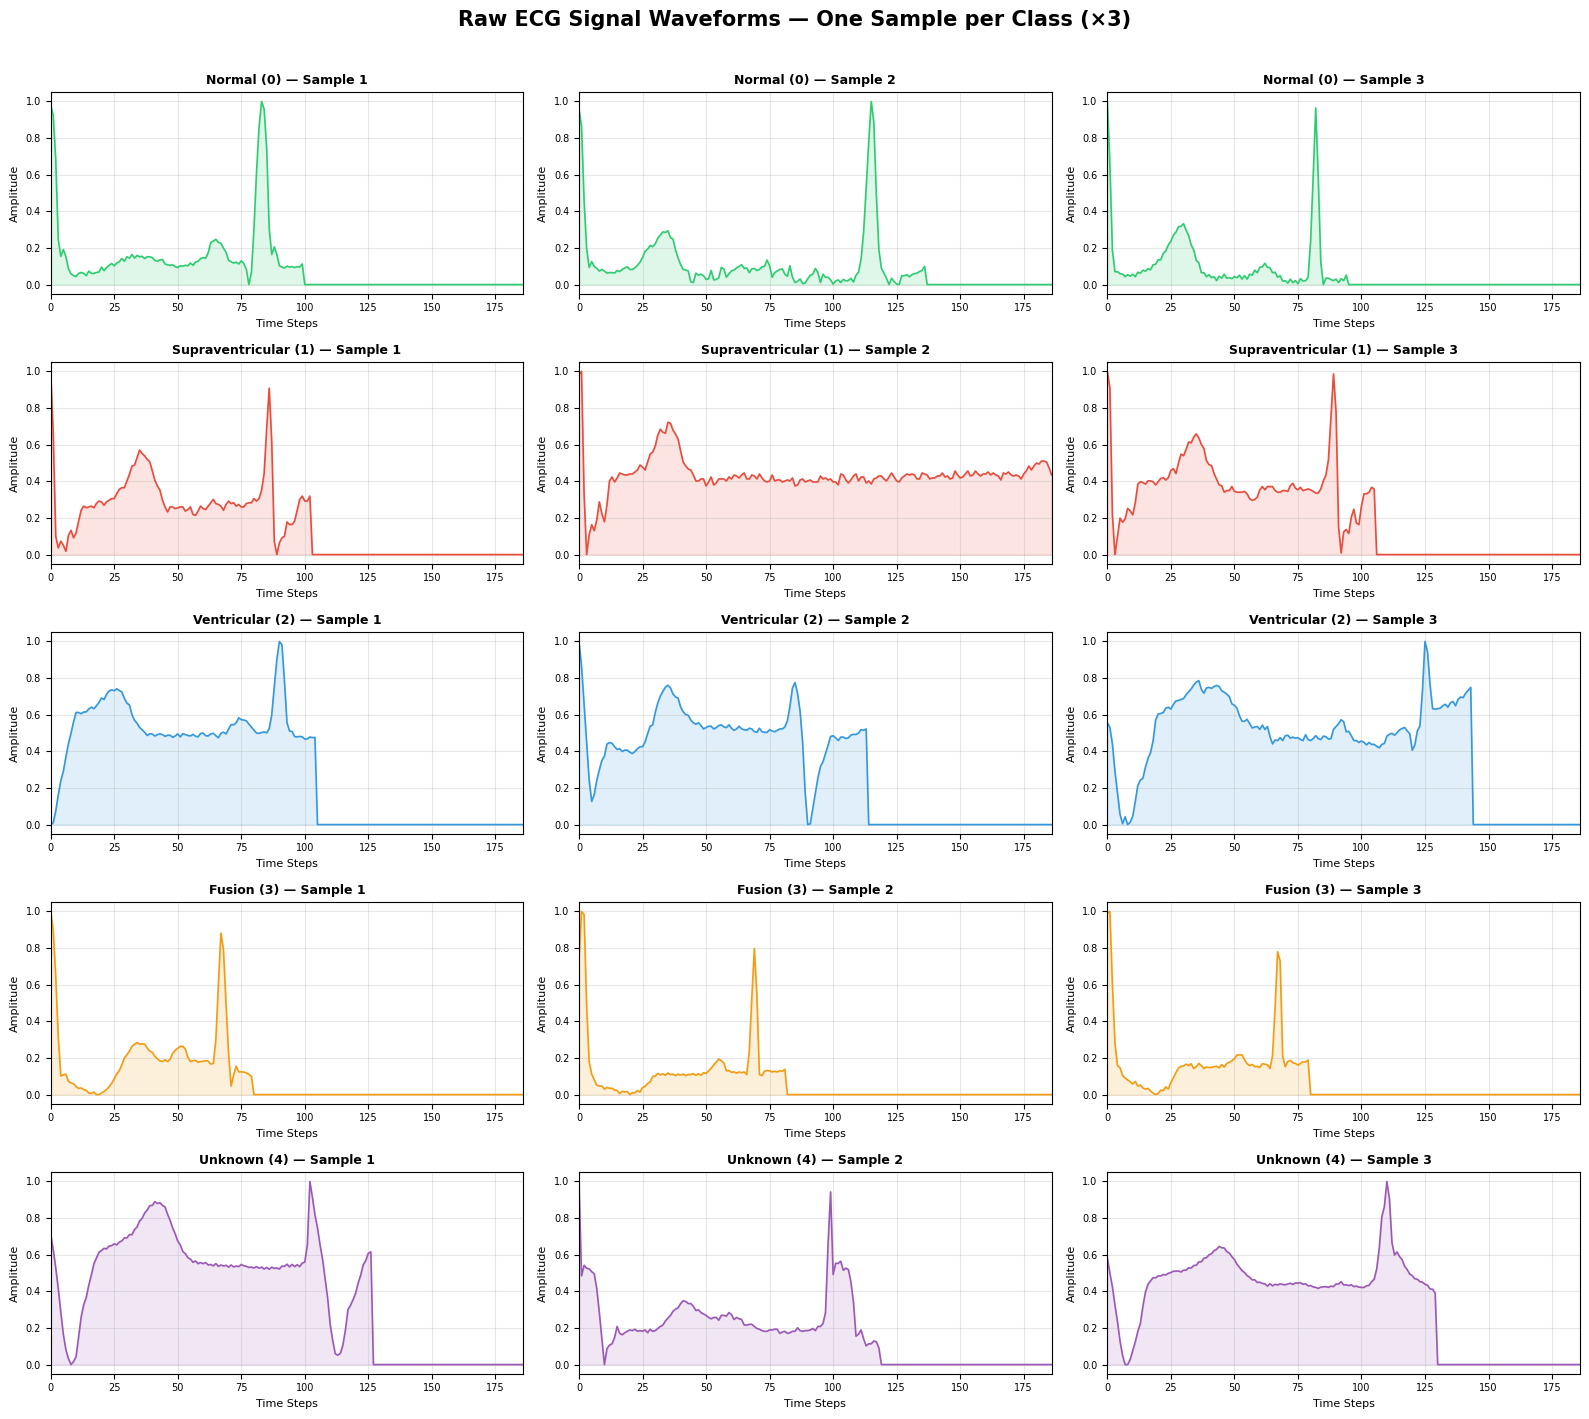

In [5]:
#  ECG waveforms
fig, axes = plt.subplots(5, 3, figsize=(16, 14))
fig.suptitle('Raw ECG Signal Waveforms — One Sample per Class (×3)', fontsize=15, fontweight='bold', y=1.01)

colors_wave = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
time_axis = np.arange(187)  # 187 time steps

for class_id in range(5):
    class_indices = np.where(y_train == class_id)[0]
    samples = class_indices[:3]
    
    for col, idx in enumerate(samples):
        ax = axes[class_id][col]
        ax.plot(time_axis, X_train_raw[idx], color=colors_wave[class_id], linewidth=1.2)
        ax.fill_between(time_axis, X_train_raw[idx], alpha=0.15, color=colors_wave[class_id])
        ax.set_title(f'{class_names[class_id]} — Sample {col+1}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Time Steps', fontsize=8)
        ax.set_ylabel('Amplitude', fontsize=8)
        ax.set_xlim(0, 186)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('ecg_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()

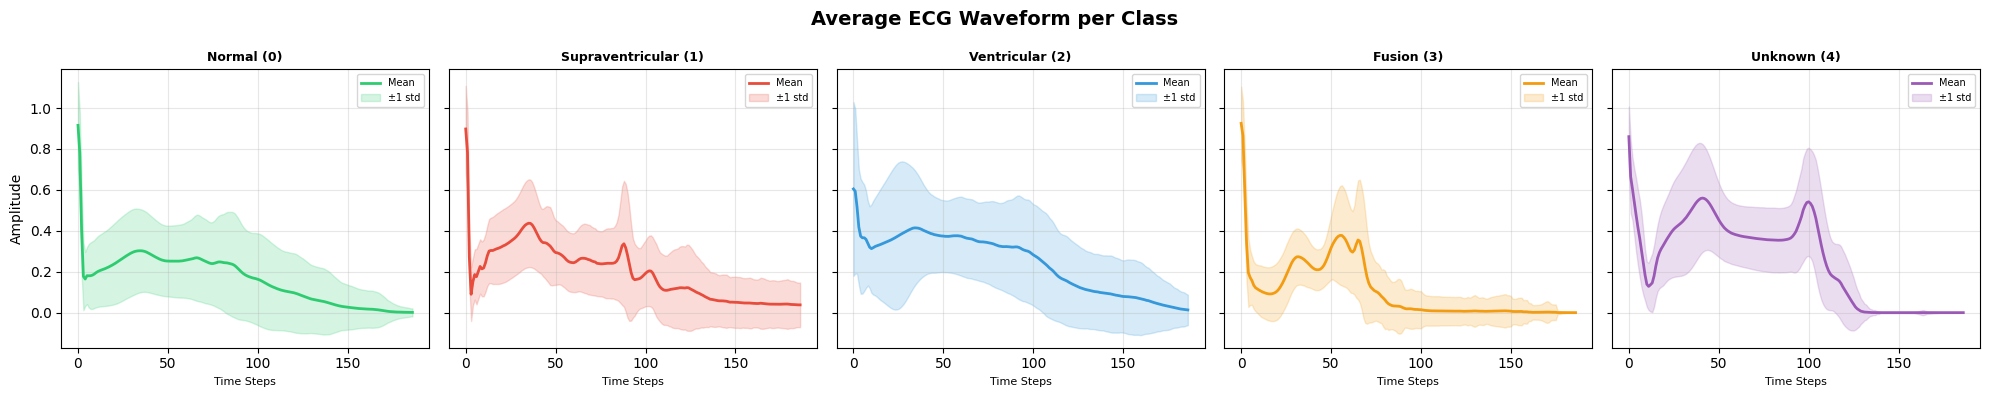

In [6]:
# mean waveform 

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('Average ECG Waveform per Class', fontsize=14, fontweight='bold')

for class_id in range(5):
    class_indices = np.where(y_train == class_id)[0]
    mean_signal = X_train_raw[class_indices].mean(axis=0)
    std_signal  = X_train_raw[class_indices].std(axis=0)
    
    ax = axes[class_id]
    ax.plot(mean_signal, color=colors_wave[class_id], linewidth=2, label='Mean')
    ax.fill_between(range(187),
                    mean_signal - std_signal,
                    mean_signal + std_signal,
                    alpha=0.2, color=colors_wave[class_id], label='±1 std')
    ax.set_title(class_names[class_id], fontsize=9, fontweight='bold')
    ax.set_xlabel('Time Steps', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Amplitude')
plt.tight_layout()
plt.savefig('average_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing

In [7]:
# Normalization
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)   
X_test_scaled  = scaler.transform(X_test_raw)        

print("Before scaling Train min/max:", X_train_raw.min().round(4), "/", X_train_raw.max().round(4))
print("After scaling Train min/max:", X_train_scaled.min().round(4), "/", X_train_scaled.max().round(4))

Before scaling Train min/max: 0.0 / 1.0
After scaling Train min/max: 0.0 / 1.0


In [8]:
# handling class imbalance
print("Class imbalance analysis:")
print("-" * 45)
total = len(y_train)
for cls in range(5):
    count = np.sum(y_train == cls)
    ratio = count / total
    bar   = '█' * int(ratio * 40)
    print(f"  Class {cls}: {count:6,}  ({ratio*100:5.1f}%)  {bar}")
print("-" * 45)
print(f"  Imbalance ratio (Class 0 vs Class 3): {np.sum(y_train==0)/np.sum(y_train==3):.0f}x")

Class imbalance analysis:
---------------------------------------------
  Class 0: 72,471  ( 82.8%)  █████████████████████████████████
  Class 1:  2,223  (  2.5%)  █
  Class 2:  5,788  (  6.6%)  ██
  Class 3:    641  (  0.7%)  
  Class 4:  6,431  (  7.3%)  ██
---------------------------------------------
  Imbalance ratio (Class 0 vs Class 3): 113x


##  Feature Extraction

In [9]:
def extract_features(X):
    """
    Extract statistical + time-domain features from ECG signals.
    
    Input : X  — numpy array of shape (N, 187)
    Output : features — numpy array of shape (N, 13)
    """
    features = []
    
    for signal in X:
        # Statistical features
        feat_mean     = np.mean(signal)            # average amplitude
        feat_std      = np.std(signal)             # signal variability
        feat_min      = np.min(signal)             # minimum amplitude
        feat_max      = np.max(signal)             # maximum amplitude
        feat_median   = np.median(signal)          # central tendency
        feat_skew     = skew(signal)               # asymmetry of distribution
        feat_kurt     = kurtosis(signal)           # peakedness of distribution
        feat_var      = np.var(signal)             # variance

        # Time-domain features
        feat_ptp      = np.ptp(signal)             # peak-to-peak amplitude (max - min)
        feat_peak_idx = np.argmax(signal)          # location of R-peak in time
        feat_energy   = np.sum(signal ** 2)        # signal energy
        
        # Zero-crossing rate 
        mean_centered = signal - feat_mean
        feat_zcr = np.sum(np.diff(np.sign(mean_centered)) != 0)

        # Number of peaks
        peaks, _ = find_peaks(signal, height=0.3)
        feat_n_peaks = len(peaks)

        features.append([
            feat_mean, feat_std, feat_min, feat_max, feat_median,
            feat_skew, feat_kurt, feat_var,
            feat_ptp, feat_peak_idx, feat_energy,
            feat_zcr, feat_n_peaks
        ])
    
    return np.array(features, dtype=np.float32)

X_train_feat = extract_features(X_train_scaled)
X_test_feat  = extract_features(X_test_scaled)

feature_names = [
    'Mean', 'Std', 'Min', 'Max', 'Median',
    'Skewness', 'Kurtosis', 'Variance',
    'Peak-to-Peak', 'Peak Index', 'Energy',
    'Zero-Crossing Rate', 'Num Peaks'
]

print(f"   Training features shape : {X_train_feat.shape}")
print(f"   Test features shape     : {X_test_feat.shape}")
print(f"   Features per signal     : {X_train_feat.shape[1]}")

   Training features shape : (87554, 13)
   Test features shape     : (21892, 13)
   Features per signal     : 13


In [10]:
feat_df = pd.DataFrame(X_train_feat, columns=feature_names)
feat_df['Label'] = y_train

print("Feature summary")
feat_df.drop('Label', axis=1).describe().round(4)

Feature summary


,Mean,Std,Min,Max,Median,Skewness,Kurtosis,Variance,Peak-to-Peak,Peak Index,Energy,Zero-Crossing Rate,Num Peaks
count,87554.0000,87554.0000,87554.0000,87554.0000,87554.0000,87554.0000,87554.0000,87554.0000,87554.0000,87554.0000,87554.0000,87554.0000,87554.0000
mean,0.1743,0.1930,0.0000,0.9997,0.1430,2.1614,8.6201,0.0401,0.9997,46.6953,15.2589,8.0421,9.3704
std,0.1056,0.0532,0.0019,0.0069,0.1677,1.5946,9.1872,0.0246,0.0075,49.7159,14.0931,5.9134,10.8746
min,0.0129,0.0682,0.0000,0.6143,0.0000,-2.5782,-1.9501,0.0046,0.6143,0.0000,1.1588,1.0000,0.0000
25%,0.0980,0.1575,0.0000,1.0000,0.0000,0.8944,1.0929,0.0248,1.0000,0.0000,6.8265,5.0000,1.0000
50%,0.1451,0.1803,0.0000,1.0000,0.0774,2.0073,5.6054,0.0325,1.0000,28.0000,10.3812,5.0000,4.0000
75%,0.2179,0.2138,0.0000,1.0000,0.2404,3.5178,14.5445,0.0457,1.0000,93.0000,17.7847,11.0000,15.0000
max,0.7620,0.4846,0.2298,1.0000,0.8597,11.1494,137.3580,0.2348,1.0000,186.0000,118.6388,88.0000,77.0000


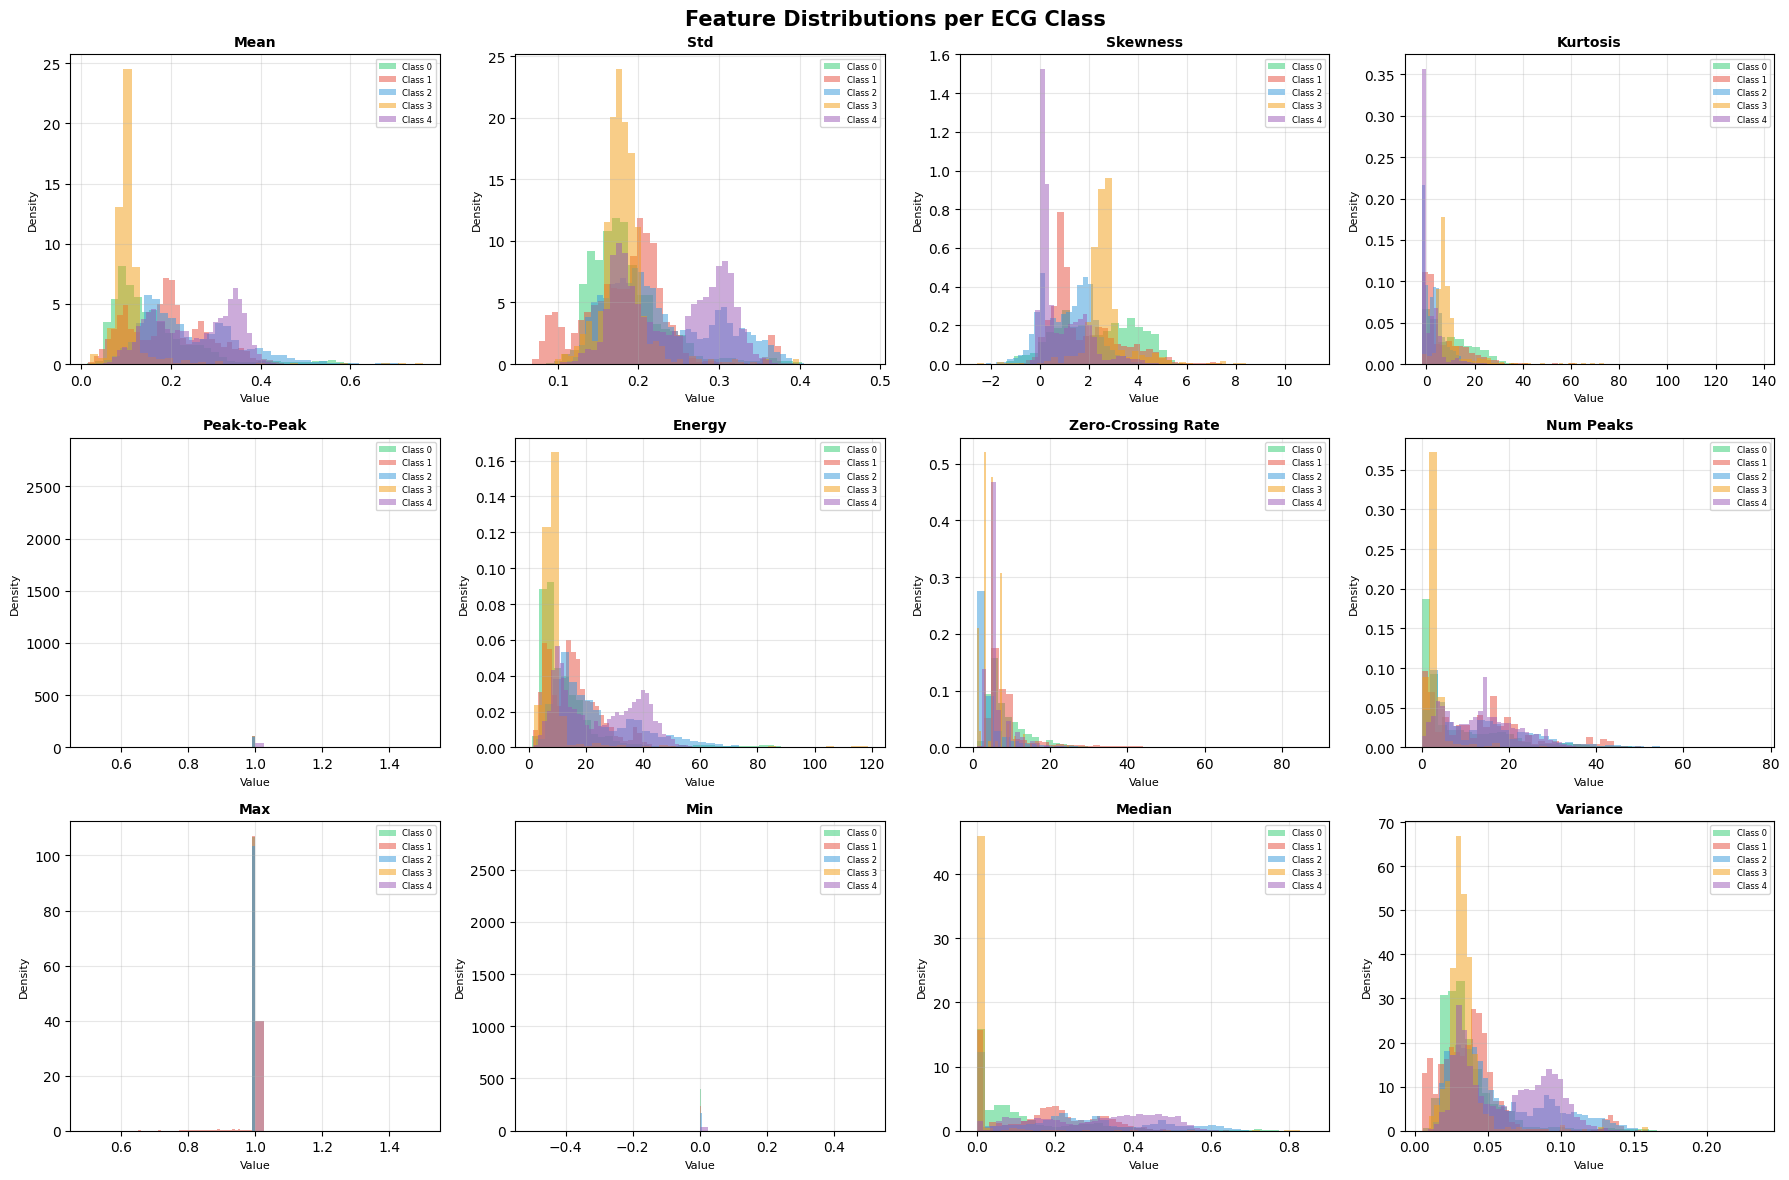

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Feature Distributions per ECG Class', fontsize=15, fontweight='bold')

plot_features = [
    'Mean', 'Std', 'Skewness', 'Kurtosis',
    'Peak-to-Peak', 'Energy', 'Zero-Crossing Rate', 'Num Peaks',
    'Max', 'Min', 'Median', 'Variance'
]

for idx, feat in enumerate(plot_features):
    ax = axes[idx // 4][idx % 4]
    for class_id in range(5):
        data = feat_df[feat_df['Label'] == class_id][feat]
        ax.hist(data, bins=40, alpha=0.5, label=f'Class {class_id}',
                color=colors_wave[class_id], density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

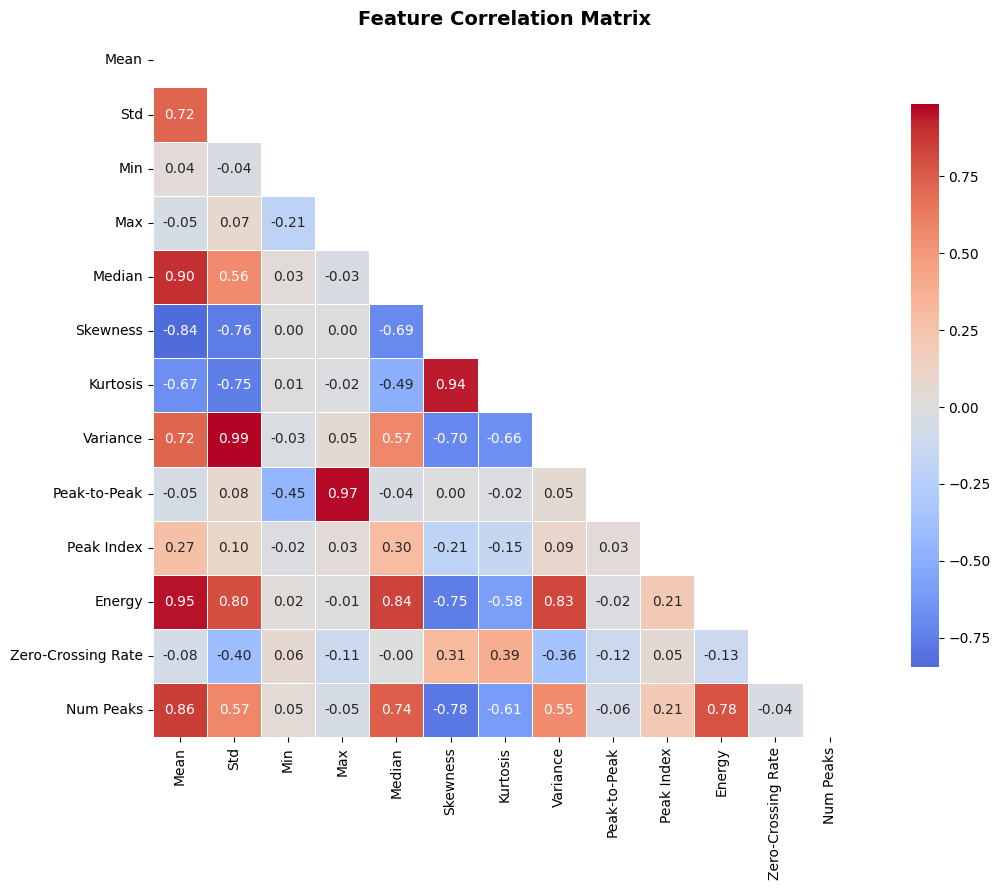

In [12]:
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = feat_df.drop('Label', axis=1).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Building

In [13]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, n_classes=5):
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")
    
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    acc      = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average='macro')
    f1_wtd   = f1_score(y_te, y_pred, average='weighted')
    
    # ROC-AUC (one-vs-rest for multiclass)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)
        try:
            roc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro')
        except:
            roc = None
    else:
        y_prob = None
        roc    = None
    
    print(f"  Accuracy      : {acc*100:.2f}%")
    print(f"  Macro F1      : {f1_macro:.4f}")
    print(f"  Weighted F1   : {f1_wtd:.4f}")
    print(f"  ROC-AUC (OvR) : {roc:.4f}" if roc else "  ROC-AUC : N/A")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=class_names, digits=3))
    
    return {
        'name'      : name,
        'model'     : model,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'accuracy'  : acc,
        'f1_macro'  : f1_macro,
        'f1_wtd'    : f1_wtd,
        'roc_auc'   : roc
    }

results = {}

In [14]:
# Model 1: Logistic Regression

lr_model = LogisticRegression(
    max_iter      = 1000,
    class_weight  = 'balanced',   # compensate for imbalance
    solver        = 'lbfgs',
    multi_class   = 'multinomial',
    random_state  = 42
)

results['LR'] = evaluate_model(
    'Logistic Regression (13 features)',
    lr_model,
    X_train_feat, y_train,
    X_test_feat,  y_test
)


  Training: Logistic Regression (13 features)
  Accuracy      : 35.92%
  Macro F1      : 0.2597
  Weighted F1   : 0.4503
  ROC-AUC (OvR) : 0.7827

  Classification Report:
                      precision    recall  f1-score   support

          Normal (0)      0.963     0.322     0.483     18118
Supraventricular (1)      0.043     0.372     0.077       556
     Ventricular (2)      0.193     0.329     0.243      1448
          Fusion (3)      0.031     0.895     0.060       162
         Unknown (4)      0.308     0.742     0.435      1608

            accuracy                          0.359     21892
           macro avg      0.308     0.532     0.260     21892
        weighted avg      0.834     0.359     0.450     21892



In [15]:
# Model 2: Random Forest
rf_feat_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = None,
    class_weight = 'balanced',
    n_jobs       = -1,
    random_state = 42
)

results['RF_feat'] = evaluate_model(
    'Random Forest (13 features)',
    rf_feat_model,
    X_train_feat, y_train,
    X_test_feat,  y_test
)


  Training: Random Forest (13 features)
  Accuracy      : 93.82%
  Macro F1      : 0.7463
  Weighted F1   : 0.9328
  ROC-AUC (OvR) : 0.9655

  Classification Report:
                      precision    recall  f1-score   support

          Normal (0)      0.941     0.990     0.965     18118
Supraventricular (1)      0.880     0.394     0.544       556
     Ventricular (2)      0.898     0.704     0.789      1448
          Fusion (3)      0.814     0.432     0.565       162
         Unknown (4)      0.944     0.803     0.868      1608

            accuracy                          0.938     21892
           macro avg      0.895     0.665     0.746     21892
        weighted avg      0.936     0.938     0.933     21892



In [16]:
# Model 2: Random Forest

rf_raw_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = None,
    class_weight = 'balanced',
    n_jobs       = -1,
    random_state = 42
)

results['RF_raw'] = evaluate_model(
    'Random Forest (187 raw time-steps)',
    rf_raw_model,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)


  Training: Random Forest (187 raw time-steps)
  Accuracy      : 97.35%
  Macro F1      : 0.8618
  Weighted F1   : 0.9717
  ROC-AUC (OvR) : 0.9910

  Classification Report:
                      precision    recall  f1-score   support

          Normal (0)      0.972     0.999     0.985     18118
Supraventricular (1)      0.973     0.590     0.735       556
     Ventricular (2)      0.983     0.876     0.926      1448
          Fusion (3)      0.835     0.593     0.693       162
         Unknown (4)      0.996     0.945     0.970      1608

            accuracy                          0.974     21892
           macro avg      0.952     0.800     0.862     21892
        weighted avg      0.973     0.974     0.972     21892



In [17]:
# Model 3: XGBoost
normal_count = np.sum(y_train == 0)
others_count = len(y_train) - normal_count
scale_w = normal_count / others_count

xgb_model = XGBClassifier(
    n_estimators      = 200,
    max_depth         = 6,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = 42,
    n_jobs            = -1
)

results['XGB'] = evaluate_model(
    'XGBoost (187 raw time-steps)',
    xgb_model,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)


  Training: XGBoost (187 raw time-steps)
  Accuracy      : 97.99%
  Macro F1      : 0.8955
  Weighted F1   : 0.9788
  ROC-AUC (OvR) : 0.9912

  Classification Report:
                      precision    recall  f1-score   support

          Normal (0)      0.980     0.998     0.989     18118
Supraventricular (1)      0.964     0.671     0.791       556
     Ventricular (2)      0.973     0.913     0.942      1448
          Fusion (3)      0.869     0.698     0.774       162
         Unknown (4)      0.992     0.970     0.981      1608

            accuracy                          0.980     21892
           macro avg      0.956     0.850     0.895     21892
        weighted avg      0.980     0.980     0.979     21892



## Evaluation & Performance Analysis

In [28]:
summary = []
for key, r in results.items():
    summary.append({
        'Model'        : r['name'],
        'Accuracy (%)' : round(r['accuracy'] * 100, 2),
        'Macro F1'     : round(r['f1_macro'], 4),
        'Weighted F1'  : round(r['f1_wtd'], 4),
        'ROC-AUC'      : round(r['roc_auc'], 4) if r['roc_auc'] else 'N/A'
    })

summary_df = pd.DataFrame(summary)
print("\n Model Performance Comparison:")
print("\n"+summary_df.to_string(index=False))


 Model Performance Comparison:

                             Model  Accuracy (%)  Macro F1  Weighted F1  ROC-AUC
 Logistic Regression (13 features)         35.92    0.2597       0.4503   0.7827
       Random Forest (13 features)         93.82    0.7463       0.9328   0.9655
Random Forest (187 raw time-steps)         97.35    0.8618       0.9717   0.9910
      XGBoost (187 raw time-steps)         97.99    0.8955       0.9788   0.9912


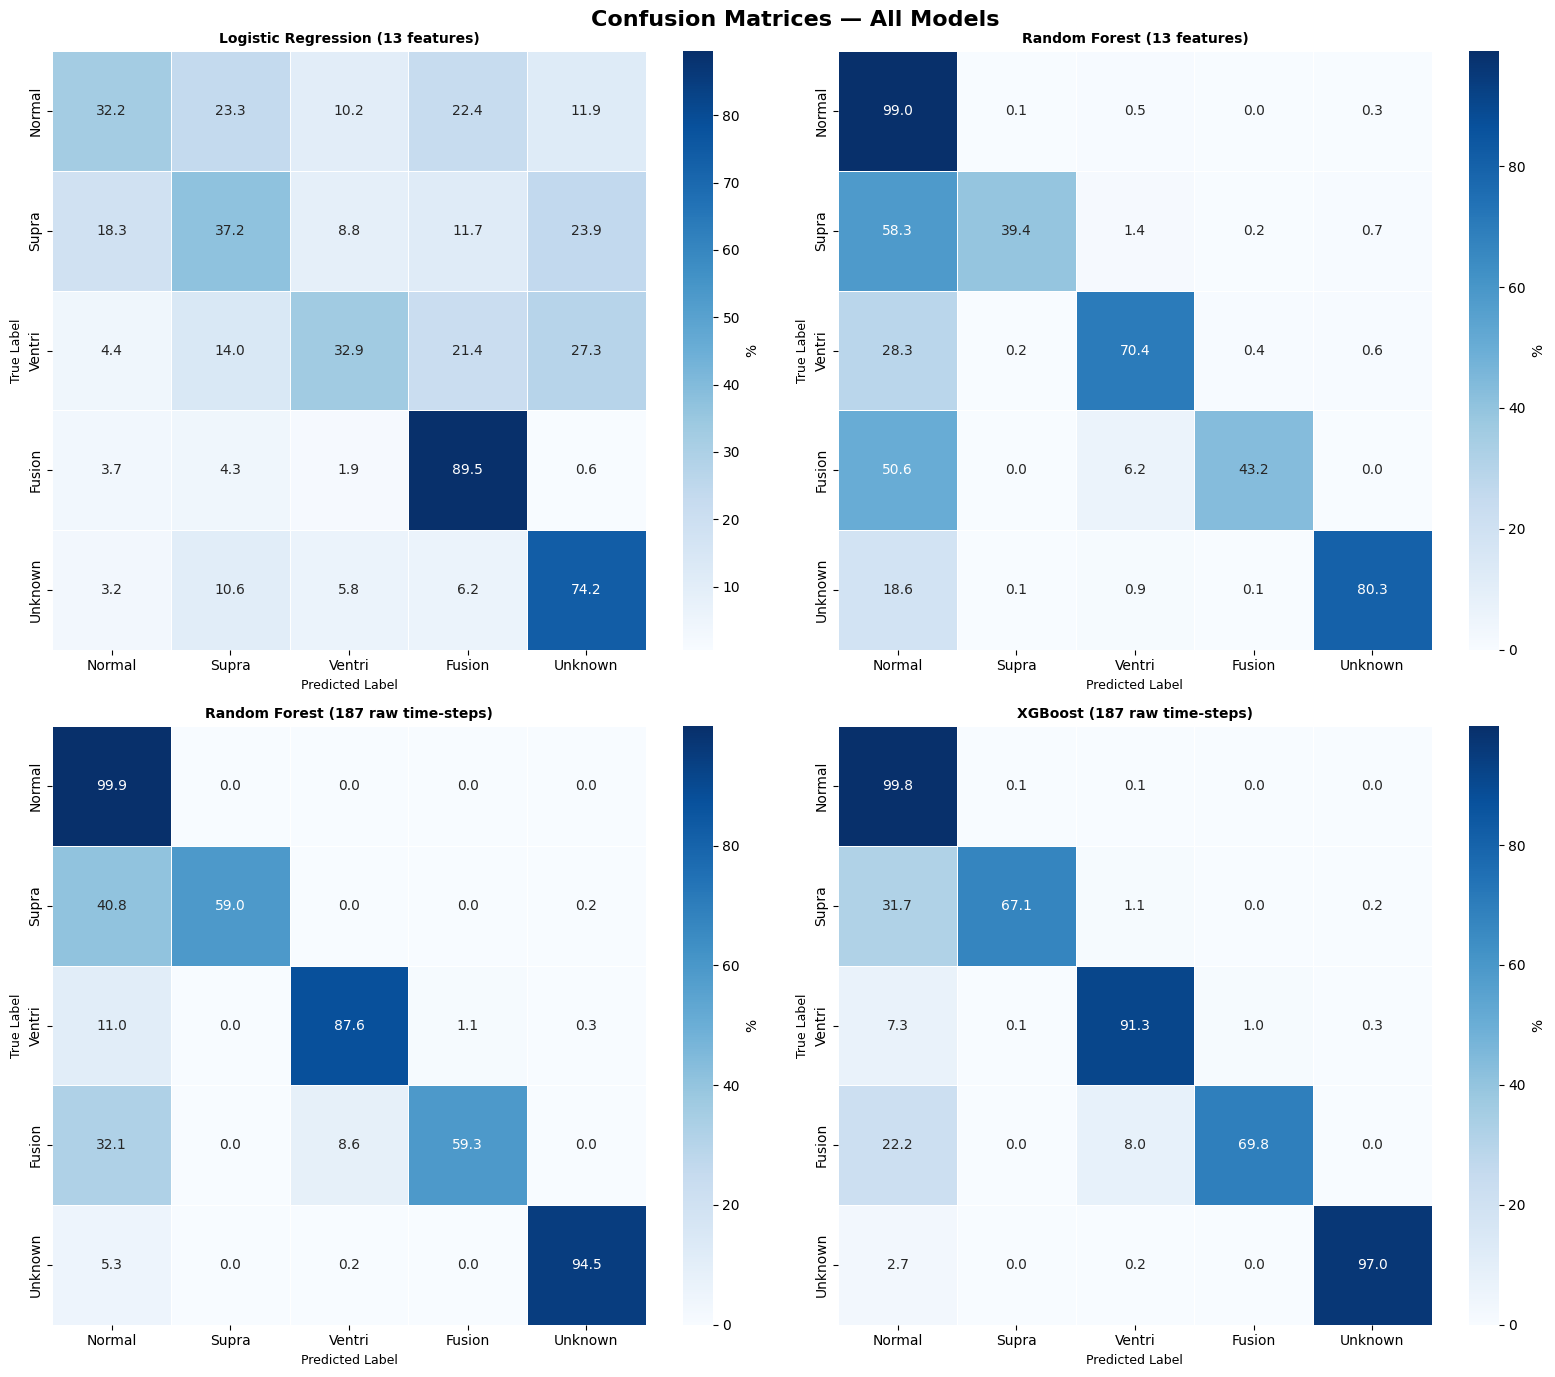

In [19]:
# Confusion matrices
short_names = ['Normal', 'Supra', 'Ventri', 'Fusion', 'Unknown']

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')

result_list = list(results.values())
ax_list     = [axes[0][0], axes[0][1], axes[1][0], axes[1][1]]

for i, (r, ax) in enumerate(zip(result_list, ax_list)):
    cm = confusion_matrix(y_test, r['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                ax=ax, linewidths=0.5, cbar_kws={'label': '%'})
    ax.set_title(r['name'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

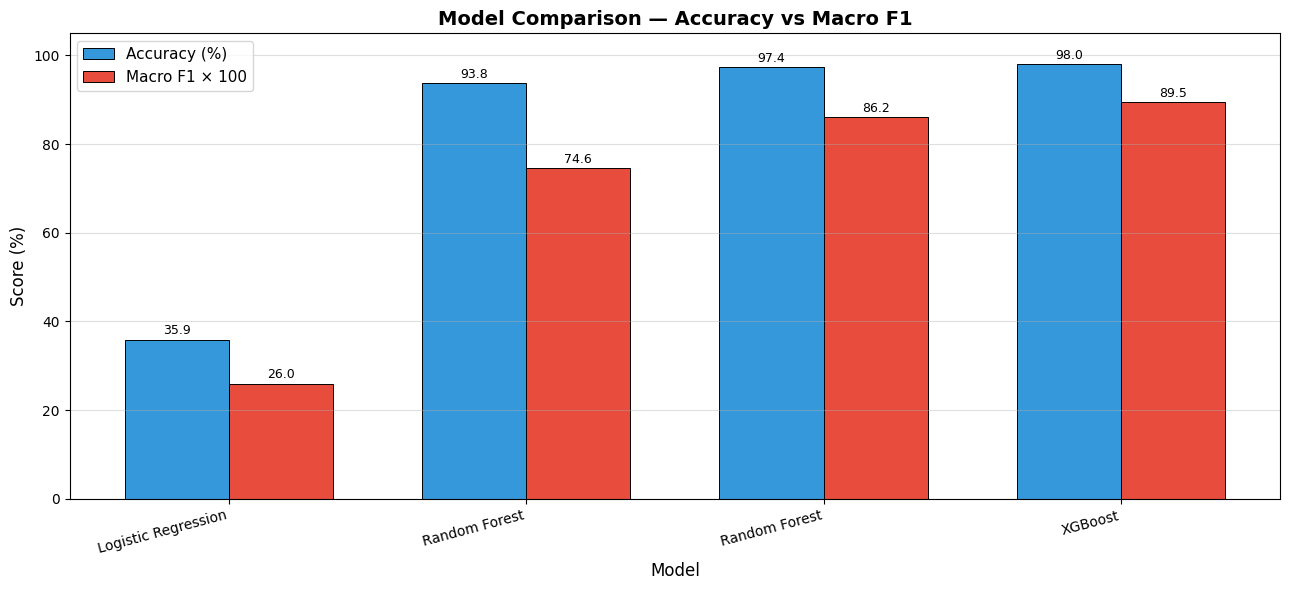

In [20]:
# Bar chart comparing accuracy and macro F1 for all models
model_labels = [r['name'].split('(')[0].strip() for r in results.values()]
accuracies   = [r['accuracy'] * 100 for r in results.values()]
f1_macros    = [r['f1_macro'] * 100 for r in results.values()]

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)',
               color='#3498db', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, f1_macros,  width, label='Macro F1 × 100',
               color='#e74c3c', edgecolor='black', linewidth=0.7)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison — Accuracy vs Macro F1', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Best model: XGBoost (187 raw time-steps)


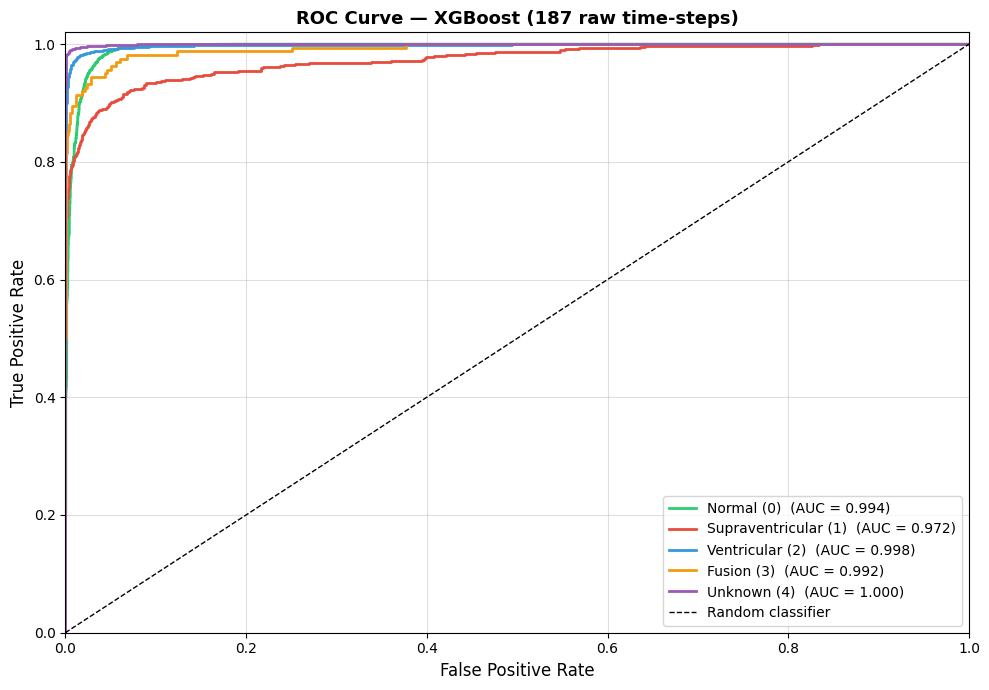

In [21]:
# ROC curve for best model
best_key = max(results, key=lambda k: results[k]['f1_macro'])
best_r   = results[best_key]
print(f"Best model: {best_r['name']}")

if best_r['y_prob'] is not None:
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
    y_prob     = best_r['y_prob']
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc_i   = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_wave[i], linewidth=2,
                label=f'{cname}  (AUC = {roc_auc_i:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC Curve — {best_r["name"]}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.4)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("ROC curve not available for this model.")

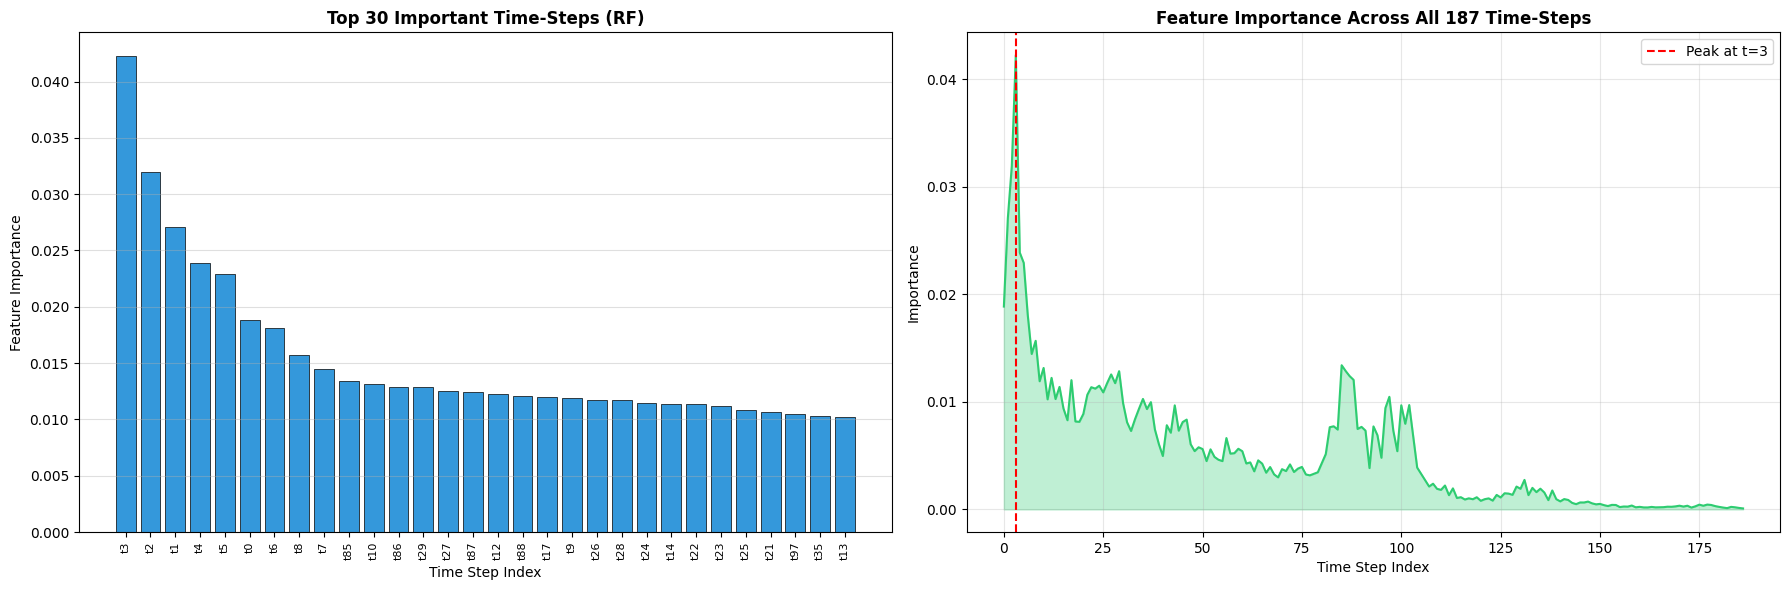

In [22]:
# Feature importance for Random Forest 
rf_raw = results['RF_raw']['model']
importances = rf_raw.feature_importances_

top_n = 30
top_indices = np.argsort(importances)[::-1][:top_n]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(range(top_n), importances[top_indices],
            color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(top_n))
axes[0].set_xticklabels([f't{i}' for i in top_indices], rotation=90, fontsize=8)
axes[0].set_title(f'Top {top_n} Important Time-Steps (RF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Step Index')
axes[0].set_ylabel('Feature Importance')
axes[0].grid(axis='y', alpha=0.4)

axes[1].plot(importances, color='#2ecc71', linewidth=1.5)
axes[1].fill_between(range(187), importances, alpha=0.3, color='#2ecc71')
axes[1].axvline(x=np.argmax(importances), color='red', linestyle='--',
                linewidth=1.5, label=f'Peak at t={np.argmax(importances)}')
axes[1].set_title('Feature Importance Across All 187 Time-Steps', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Step Index')
axes[1].set_ylabel('Importance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Summary & Conclusion

In [23]:
print("FINAL PROJECT RESULTS SUMMARY")

print(f"\n   Dataset        : MIT-BIH Arrhythmia (ECG Heartbeat)")
print(f"   Training size  : {len(y_train):,} samples")
print(f"   Test size      : {len(y_test):,} samples")
print(f"   Classes        : 5 (Normal + 4 abnormal types)")
print(f"   Features used  : 187 raw time-steps + 13 extracted features")

print("\n")
print(f"{'Model':<40} {'Accuracy':>10} {'Macro F1':>10} {'AUC':>10}")
print("-"*80)
for key, r in results.items():
    auc_str = f"{r['roc_auc']:.4f}" if r['roc_auc'] else 'N/A'
    print(f"{r['name']:<40} {r['accuracy']*100:>9.2f}% {r['f1_macro']:>10.4f} {auc_str:>10}")
print("-"*80)

best = results[best_key]
print(f"\n Best Model     : {best['name']}")
print(f"   Accuracy       : {best['accuracy']*100:.2f}%")
print(f"   Macro F1       : {best['f1_macro']:.4f}")
print(f"   ROC-AUC        : {best['roc_auc']:.4f}" if best['roc_auc'] else "")


FINAL PROJECT RESULTS SUMMARY

   Dataset        : MIT-BIH Arrhythmia (ECG Heartbeat)
   Training size  : 87,554 samples
   Test size      : 21,892 samples
   Classes        : 5 (Normal + 4 abnormal types)
   Features used  : 187 raw time-steps + 13 extracted features


Model                                      Accuracy   Macro F1        AUC
--------------------------------------------------------------------------------
Logistic Regression (13 features)            35.92%     0.2597     0.7827
Random Forest (13 features)                  93.82%     0.7463     0.9655
Random Forest (187 raw time-steps)           97.35%     0.8618     0.9910
XGBoost (187 raw time-steps)                 97.99%     0.8955     0.9912
--------------------------------------------------------------------------------

 Best Model     : XGBoost (187 raw time-steps)
   Accuracy       : 97.99%
   Macro F1       : 0.8955
   ROC-AUC        : 0.9912


In [30]:
print("CONCLUSIONS")
print("""
Objective 1 - Apply ML to real-world signal data:
  1. The MIT-BIH ECG dataset contains real patient heartbeat recordings.
  2. ML models successfully classified 5 heartbeat categories from raw signals.

Objective 2 - Preprocessing, Feature Extraction, Model Building:
  1. Preprocessing: MinMaxScaler normalization + class_weight balancing
  2. Feature Extraction: 13 statistical/time-domain features + raw 187 time-steps
  3. Models built: Logistic Regression, Random Forest (x2), XGBoost

Objective 3 - Analyze model performance:
  1. Logistic Regression provides a solid baseline but struggles with minority classes
  2. Random Forest with hand-crafted features shows improvement
  3. Random Forest and XGBoost on raw time-steps achieve highest accuracy
  4. Tree-based models outperform linear models because ECG patterns are non-linear
  5. Macro F1 is more informative than accuracy due to class imbalance
""")

CONCLUSIONS

Objective 1 - Apply ML to real-world signal data:
  1. The MIT-BIH ECG dataset contains real patient heartbeat recordings.
  2. ML models successfully classified 5 heartbeat categories from raw signals.

Objective 2 - Preprocessing, Feature Extraction, Model Building:
  1. Preprocessing: MinMaxScaler normalization + class_weight balancing
  2. Feature Extraction: 13 statistical/time-domain features + raw 187 time-steps
  3. Models built: Logistic Regression, Random Forest (x2), XGBoost

Objective 3 - Analyze model performance:
  1. Logistic Regression provides a solid baseline but struggles with minority classes
  2. Random Forest with hand-crafted features shows improvement
  3. Random Forest and XGBoost on raw time-steps achieve highest accuracy
  4. Tree-based models outperform linear models because ECG patterns are non-linear
  5. Macro F1 is more informative than accuracy due to class imbalance

